# Data exploration for baseline model
In this notebook, we conduct an exploratory data analysis for the baseline model, whose variables include Hour, Day, Month, Public Holiday, School Holiday, Site, Direction (in and out), Hour × Day, and Hour × Direction. We also examine the important external continuous variable Fuel Price.

First, we check for missing values and find that there are no missing values among these variables. We then examine the counts for each variable and find that Hour, Day, Month, Site, and Direction are relatively balanced in their distributions. In contrast, Public Holiday and School Holiday show a more imbalanced pattern, with fewer cyclist counts during holiday periods. As for Fuel Price, its distribution lies within a moderate range, and fuel prices fluctuate over time.

Then, for the response variable (count_rescaled), the distribution is highly concentrated at low values and strongly right-skewed, with many zero values. Finally, we examine the correlations among the variables. The positive Spearman correlation indicates that cyclist traffic tends to be higher in later time intervals, but the relationship is not purely linear and should therefore be analysed through the full count model rather than through correlation alone.

### Import packages

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

### Load data

In [21]:
project_folder = Path("..")
processed_folder = project_folder / "data" / "processed"
eda_folder = processed_folder / "eda_model1"
eda_folder.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="Blues")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

df = pd.read_csv(processed_folder / "counts_model_final.csv", parse_dates=["date", "installation_date"])

### Identify category variables and interaction terms

In [22]:
eda_df = df.copy()

# Standardize / rename variables for EDA
eda_df["Hour"] = eda_df["hour_bin"]
eda_df["Day"] = pd.Categorical(
    eda_df["weekday"],
    categories=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    ordered=True
)
eda_df["Month"] = pd.Categorical(
    eda_df["month"],
    categories=list(range(1, 13)),
    ordered=True
)
eda_df["PublicHoliday"] = pd.Categorical(
    eda_df["is_public_holiday"].map({0: "No", 1: "Yes"}),
    categories=["No", "Yes"],
    ordered=True
)
eda_df["SchoolHoliday"] = pd.Categorical(
    eda_df["is_school_holiday"].map({0: "No", 1: "Yes"}),
    categories=["No", "Yes"],
    ordered=True
)
eda_df["Site"] = eda_df["site_id"].astype(str)
eda_df["Direction"] = pd.Categorical(
    eda_df["direction"]
)

# Interaction terms
eda_df["Hour_Day"] = eda_df["Hour"].astype(str) + "_" + eda_df["Day"].astype(str)
eda_df["Hour_Direction"] = eda_df["Hour"].astype(str) + "_" + eda_df["Direction"].astype(str)

### Missing value check for categorical variables and interaction terms

In [23]:
model_vars = [
    "Hour", "Day", "Month", "PublicHoliday", "SchoolHoliday",
    "Site", "Direction", "Hour_Day", "Hour_Direction"
]

missing_summary = (
    eda_df[model_vars]
    .isna()
    .sum()
    .rename("missing_n")
    .reset_index()
    .rename(columns={"index": "variable"})
)
missing_summary["missing_pct"] = missing_summary["missing_n"] / len(eda_df)

missing_summary.to_csv(eda_folder / "missing_summary_model1.csv", index=False)
missing_summary

,variable,missing_n,missing_pct
0,Hour,0,0.0
1,Day,0,0.0
2,Month,0,0.0
3,PublicHoliday,0,0.0
4,SchoolHoliday,0,0.0
5,Site,0,0.0
6,Direction,0,0.0
7,Hour_Day,0,0.0
8,Hour_Direction,0,0.0


### Counts table for categorical variable

In [24]:
# -------------------------
# Counts summary table + plots for categorical variables
# -------------------------

# output folder
projectfolder = Path("..")
processedfolder = projectfolder / "data" / "processed"
eda_folder = processedfolder / "edamodel1"
eda_folder.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# -------------------------
# If eda_df is not yet prepared, create it from df
# -------------------------
eda_df = df.copy()

eda_df["Hour"] = eda_df["hour_bin"]
eda_df["Day"] = pd.Categorical(
    eda_df["weekday"],
    categories=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    ordered=True
)
eda_df["Month"] = pd.Categorical(
    eda_df["month"],
    categories=list(range(1, 13)),
    ordered=True
)
eda_df["PublicHoliday"] = pd.Categorical(
    eda_df["is_public_holiday"].replace({0: "No", 1: "Yes"}),
    categories=["No", "Yes"],
    ordered=True
)
eda_df["SchoolHoliday"] = pd.Categorical(
    eda_df["is_school_holiday"].replace({0: "No", 1: "Yes"}),
    categories=["No", "Yes"],
    ordered=True
)
eda_df["Site"] = eda_df["site_id"].astype(str)
eda_df["Direction"] = pd.Categorical(eda_df["direction"])
eda_df["Hour_Day"] = eda_df["Hour"].astype(str) + "_" + eda_df["Day"].astype(str)
eda_df["Hour_Direction"] = eda_df["Hour"].astype(str) + "_" + eda_df["Direction"].astype(str)

# -------------------------
# 1) Compact summary table
# -------------------------

def make_count_summary(data, var_name):
    s = data[var_name]
    tab = s.value_counts(dropna=False)
    total_n = len(s)
    nonmissing_n = s.notna().sum()
    missing_n = s.isna().sum()
    n_levels = s.nunique(dropna=True)
    max_share = (tab.iloc[0] / total_n) if len(tab) > 0 else np.nan
    min_share = (tab.iloc[-1] / total_n) if len(tab) > 0 else np.nan

    return pd.DataFrame({
        "variable": [var_name],
        "total_n": [total_n],
        "nonmissing_n": [nonmissing_n],
        "missing_n": [missing_n],
        "missing_share": [missing_n / total_n],
        "n_levels": [n_levels],
        "largest_level_n": [tab.iloc[0] if len(tab) > 0 else np.nan],
        "largest_level_share": [max_share],
        "smallest_level_n": [tab.iloc[-1] if len(tab) > 0 else np.nan],
        "smallest_level_share": [min_share]
    })

summary_vars = [
    "Hour", "Day", "Month", "PublicHoliday",
    "SchoolHoliday", "Direction", "Site",
    "Hour_Day", "Hour_Direction"
]

counts_summary_compact = pd.concat(
    [make_count_summary(eda_df, v) for v in summary_vars],
    ignore_index=True
)

counts_summary_compact.to_csv(eda_folder / "counts_summary_compact.csv", index=False)
counts_summary_compact

,variable,total_n,nonmissing_n,missing_n,missing_share,n_levels,largest_level_n,largest_level_share,smallest_level_n,smallest_level_share
0,Hour,4587736,4587736,0,0.0,12,382495,0.083373,381172,0.083085
1,Day,4587736,4587736,0,0.0,7,657070,0.143223,654079,0.142571
2,Month,4587736,4587736,0,0.0,12,408688,0.089083,340124,0.074138
3,PublicHoliday,4587736,4587736,0,0.0,2,4414804,0.962306,172932,0.037694
4,SchoolHoliday,4587736,4587736,0,0.0,2,3281386,0.715252,1306350,0.284748
5,Direction,4587736,4587736,0,0.0,2,2293874,0.500001,2293862,0.499999
6,Site,4587736,4587736,0,0.0,149,35056,0.007641,854,0.000186
7,Hour_Day,4587736,4587736,0,0.0,84,54770,0.011938,53496,0.011661
8,Hour_Direction,4587736,4587736,0,0.0,24,191248,0.041687,190586,0.041542


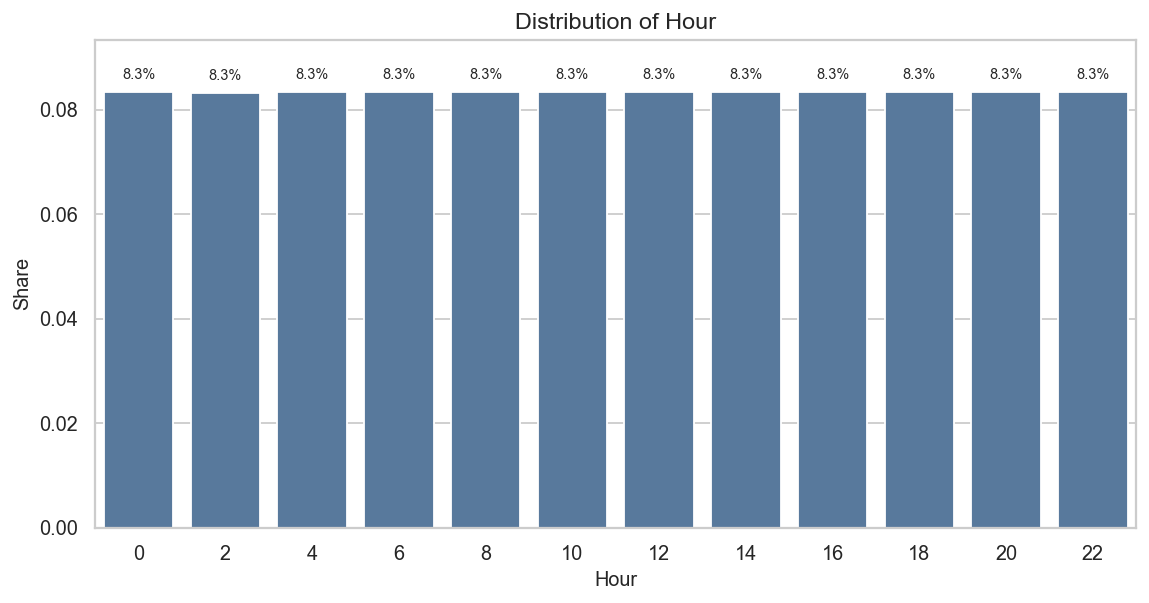

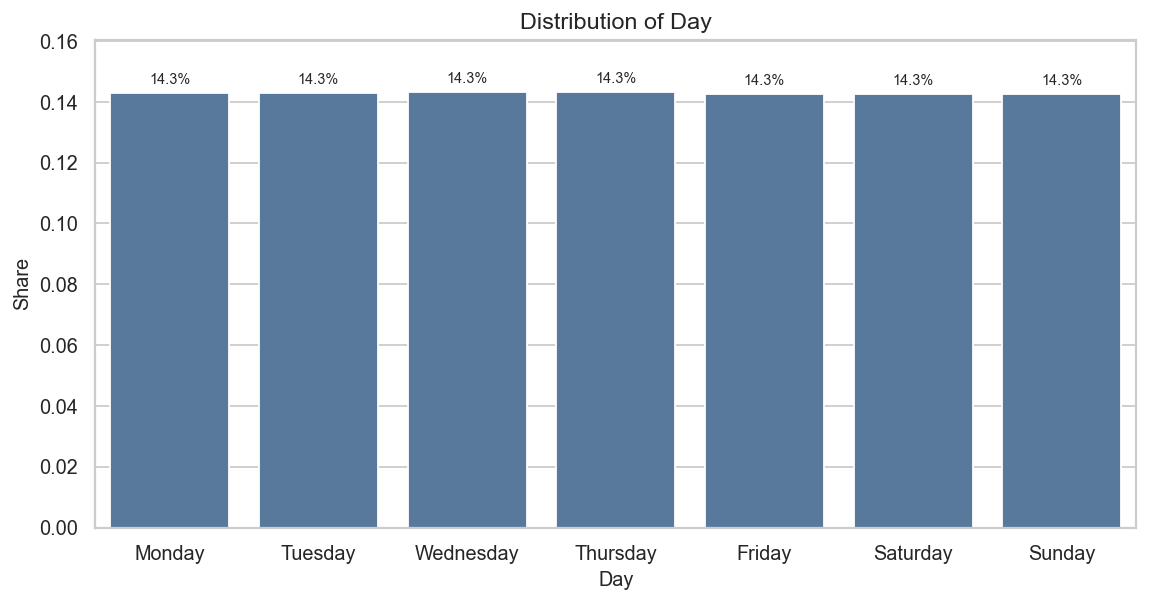

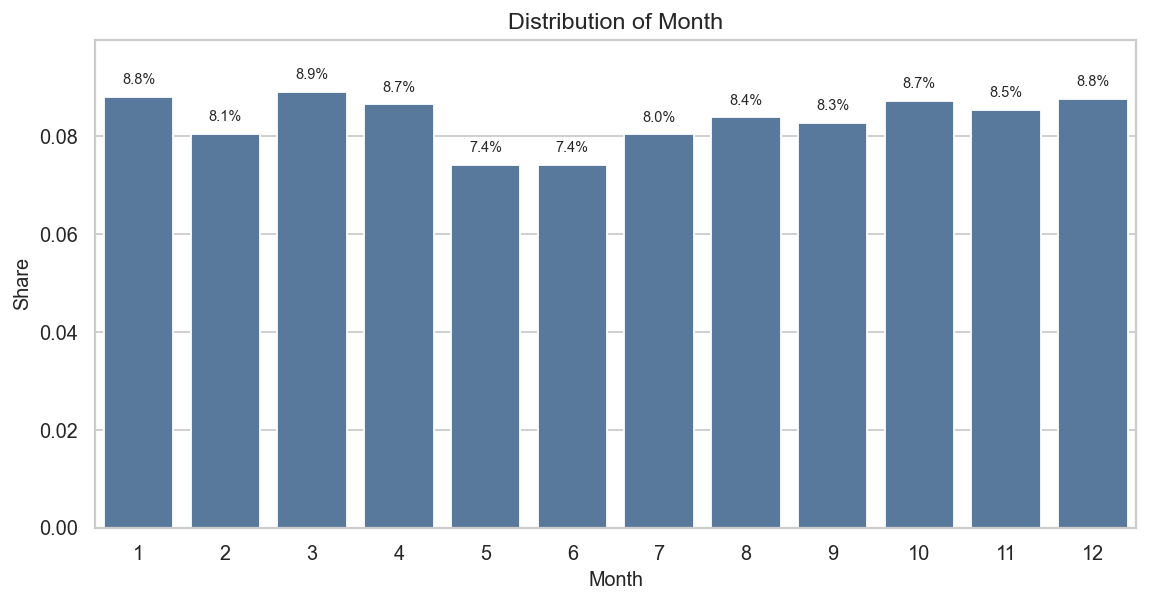

In [25]:
# -------------------------
# 2) Ordered bar charts: Hour / Day / Month
# -------------------------

ordered_vars = {
    "Hour": list(sorted(eda_df["Hour"].dropna().unique())),
    "Day": ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    "Month": list(range(1, 13))
}

for var_name, order in ordered_vars.items():
    plot_df = (
        eda_df[var_name]
        .value_counts(dropna=False)
        .reindex(order)
        .rename_axis("level")
        .reset_index(name="n")
    )
    plot_df["share"] = plot_df["n"] / plot_df["n"].sum()

    plt.figure(figsize=(9, 4.8))
    ax = sns.barplot(data=plot_df, x="level", y="share", color="#4C78A8")
    ax.set_title(f"Distribution of {var_name}")
    ax.set_xlabel(var_name)
    ax.set_ylabel("Share")
    ax.set_ylim(0, plot_df["share"].max() * 1.12)

    for i, v in enumerate(plot_df["share"]):
        ax.text(i, v + 0.002, f"{v:.1%}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.savefig(eda_folder / f"{var_name.lower()}_distribution_bar.png", bbox_inches="tight")
    plt.show()
    plt.close()

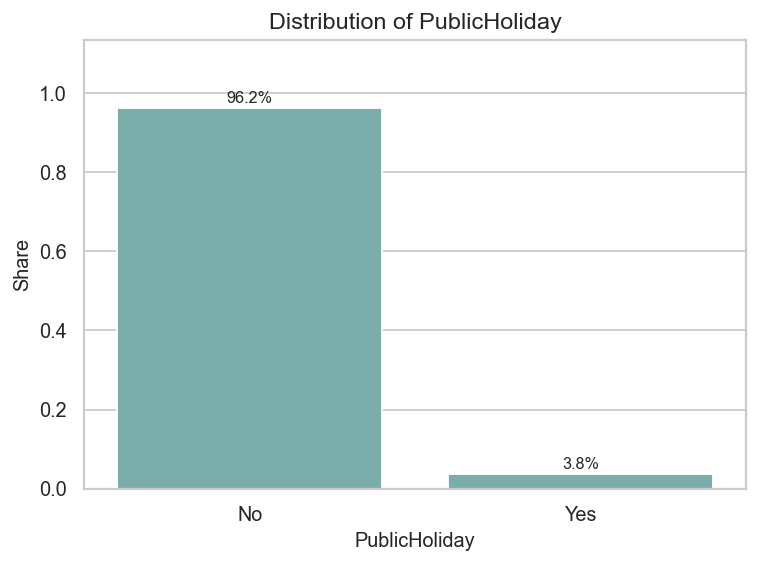

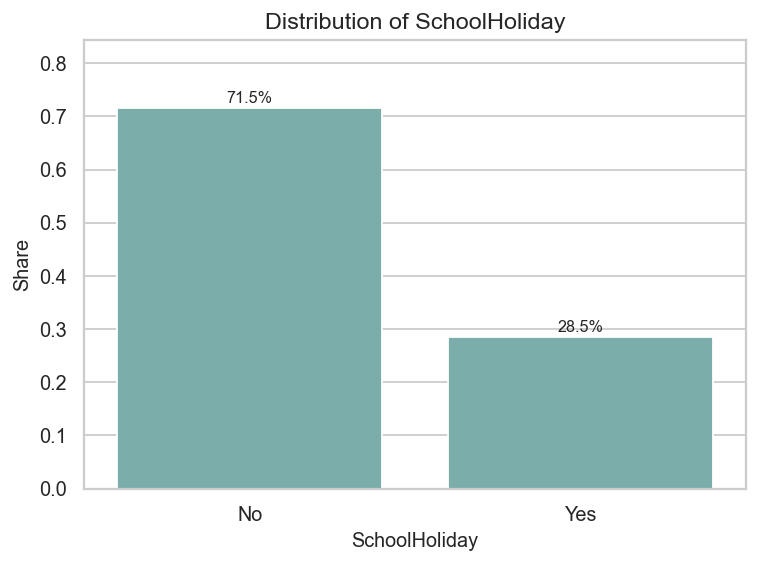

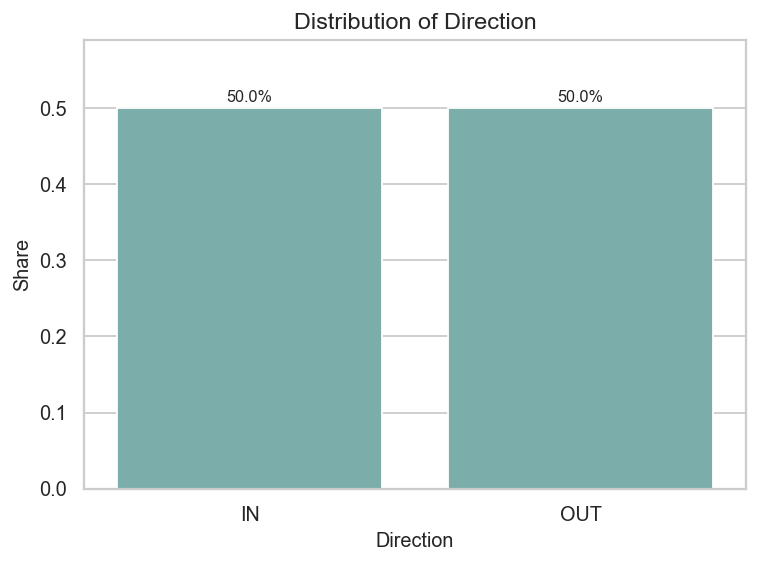

In [26]:
# -------------------------
# 3) Binary bar charts: PublicHoliday / SchoolHoliday / Direction
# -------------------------

binary_vars = ["PublicHoliday", "SchoolHoliday", "Direction"]

for var_name in binary_vars:
    plot_df = (
        eda_df[var_name]
        .value_counts(dropna=False)
        .rename_axis("level")
        .reset_index(name="n")
    )
    plot_df["share"] = plot_df["n"] / plot_df["n"].sum()

    plt.figure(figsize=(6, 4.5))
    ax = sns.barplot(data=plot_df, x="level", y="share", color="#72B7B2")
    ax.set_title(f"Distribution of {var_name}")
    ax.set_xlabel(var_name)
    ax.set_ylabel("Share")
    ax.set_ylim(0, plot_df["share"].max() * 1.18)

    for i, v in enumerate(plot_df["share"]):
        ax.text(i, v + 0.005, f"{v:.1%}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.savefig(eda_folder / f"{var_name.lower()}_distribution_bar.png", bbox_inches="tight")
    plt.show()
    plt.close()

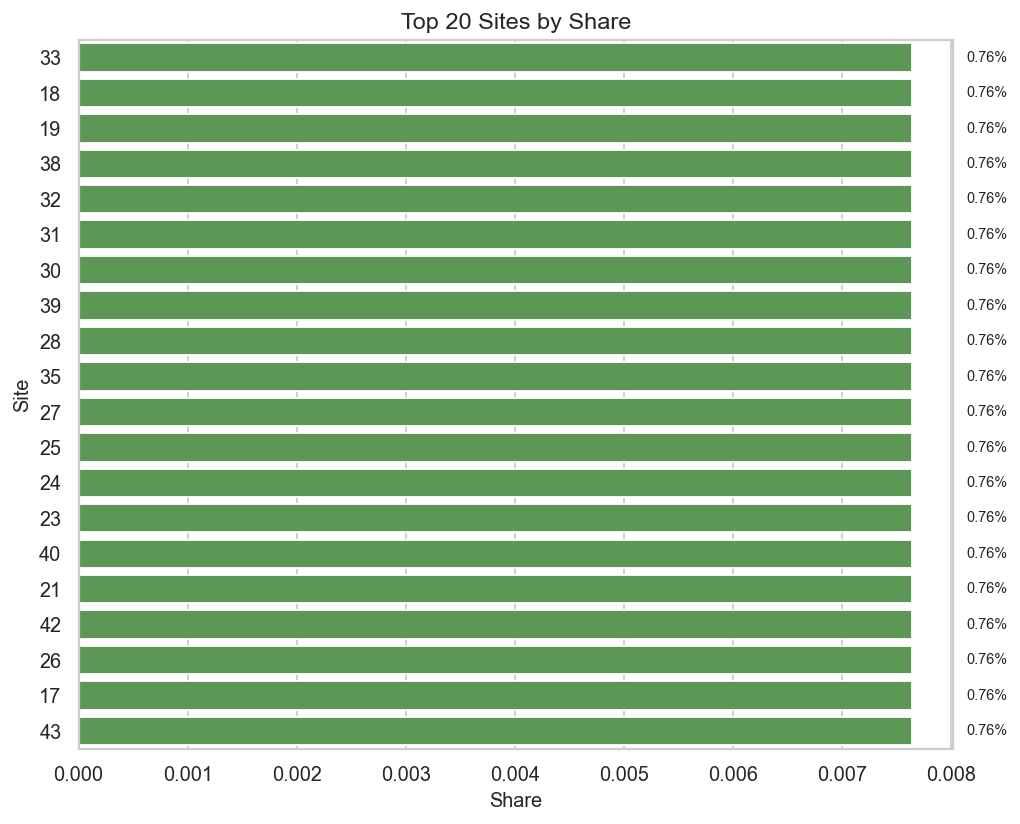

In [27]:
# -------------------------
# 4) Top-N bar chart for Site
# -------------------------

top_n = 20

site_plot_df = (
    eda_df["Site"]
    .value_counts(dropna=False)
    .head(top_n)
    .sort_values(ascending=True)
    .rename_axis("level")
    .reset_index(name="n")
)

site_plot_df["share"] = site_plot_df["n"] / len(eda_df)

plt.figure(figsize=(8, 6.5))
ax = sns.barplot(data=site_plot_df, x="share", y="level", color="#54A24B")
ax.set_title(f"Top {top_n} Sites by Share")
ax.set_xlabel("Share")
ax.set_ylabel("Site")

for i, v in enumerate(site_plot_df["share"]):
    ax.text(v + 0.0005, i, f"{v:.2%}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(eda_folder / "site_top20_bar.png", bbox_inches="tight")
plt.show()
plt.close()

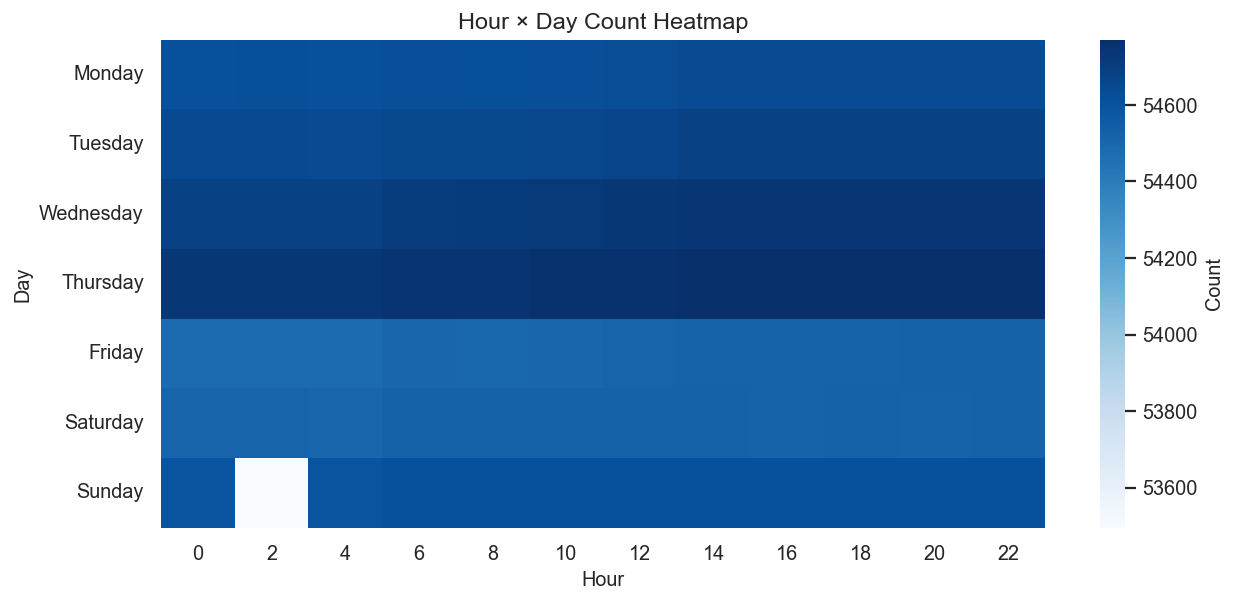

In [28]:
# -------------------------
# 5) Heatmap for Hour x Day
# -------------------------

hour_day_heatmap = (
    eda_df
    .groupby(["Day", "Hour"], observed=False)
    .size()
    .unstack(fill_value=0)
)

hour_day_heatmap = hour_day_heatmap.reindex(
    index=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)

hour_day_heatmap = hour_day_heatmap.reindex(
    columns=sorted(hour_day_heatmap.columns)
)

plt.figure(figsize=(10, 4.8))
sns.heatmap(hour_day_heatmap, cmap="Blues", cbar_kws={"label": "Count"})
plt.title("Hour × Day Count Heatmap")
plt.xlabel("Hour")
plt.ylabel("Day")
plt.tight_layout()
plt.savefig(eda_folder / "hour_day_heatmap.png", bbox_inches="tight")
plt.show()
plt.close()

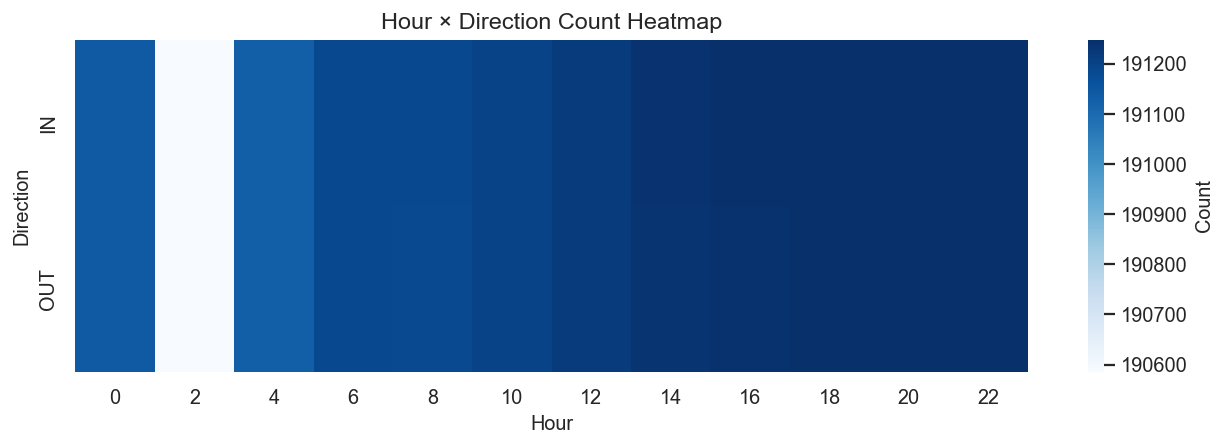

In [29]:
# -------------------------
# 6) Heatmap for Hour x Direction
# -------------------------

hour_direction_heatmap = (
    eda_df
    .groupby(["Direction", "Hour"], observed=False)
    .size()
    .unstack(fill_value=0)
)

hour_direction_heatmap = hour_direction_heatmap.reindex(columns=sorted(hour_direction_heatmap.columns))

plt.figure(figsize=(10, 3.6))
sns.heatmap(hour_direction_heatmap, cmap="Blues", cbar_kws={"label": "Count"})
plt.title("Hour × Direction Count Heatmap")
plt.xlabel("Hour")
plt.ylabel("Direction")
plt.tight_layout()
plt.savefig(eda_folder / "hour_direction_heatmap.png", bbox_inches="tight")
plt.show()
plt.close()

### Data exploration for Fuel prices

In [30]:
fuel_df = df.copy()

fuel_var = "fuel_price_petrol_95"

fuel_df["FuelPrice"] = fuel_df[fuel_var]

# -------------------------
# Basic count / completeness summary
# -------------------------
fuel_count_summary = pd.DataFrame({
    "metric": [
        "total_rows",
        "non_missing_rows",
        "missing_rows",
        "missing_share",
        "unique_values_row_level"
    ],
    "value": [
        len(fuel_df),
        fuel_df["FuelPrice"].notna().sum(),
        fuel_df["FuelPrice"].isna().sum(),
        fuel_df["FuelPrice"].isna().mean(),
        fuel_df["FuelPrice"].nunique()
    ]
})

fuel_count_summary.to_csv(eda_folder / "fuelprice_count_summary.csv", index=False)
fuel_count_summary

,metric,value
0,total_rows,4587736.0
1,non_missing_rows,4587736.0
2,missing_rows,0.0
3,missing_share,0.0
4,unique_values_row_level,205.0


In [31]:
# -------------------------
# Daily-level fuel price data
# -------------------------
fuel_daily = (
    fuel_df[["date", "FuelPrice"]]
    .drop_duplicates()
    .sort_values("date")
    .reset_index(drop=True)
)

fuel_daily_summary = pd.DataFrame({
    "metric": [
        "unique_days",
        "non_missing_days",
        "missing_days",
        "unique_values_daily_level"
    ],
    "value": [
        len(fuel_daily),
        fuel_daily["FuelPrice"].notna().sum(),
        fuel_daily["FuelPrice"].isna().sum(),
        fuel_daily["FuelPrice"].nunique()
    ]
})

fuel_daily_summary.to_csv(eda_folder / "fuelprice_daily_summary.csv", index=False)
fuel_daily_summary

,metric,value
0,unique_days,1461
1,non_missing_days,1461
2,missing_days,0
3,unique_values_daily_level,205


In [32]:
# -------------------------
# Binned counts table
# -------------------------
n_bins = 20

fuel_daily_nonmissing = fuel_daily.dropna(subset=["FuelPrice"]).copy()

fuel_daily_nonmissing["FuelPrice_bin"] = pd.cut(
    fuel_daily_nonmissing["FuelPrice"],
    bins=n_bins
)

fuel_bin_counts = (
    fuel_daily_nonmissing["FuelPrice_bin"]
    .value_counts(sort=False)
    .rename_axis("FuelPrice_bin")
    .reset_index(name="n")
)

fuel_bin_counts["share"] = fuel_bin_counts["n"] / fuel_bin_counts["n"].sum()

fuel_bin_counts.to_csv(eda_folder / "fuelprice_binned_counts.csv", index=False)
fuel_bin_counts

,FuelPrice_bin,n,share
0,"(1447.537, 1481.332]",42,0.028747
1,"(1481.332, 1514.463]",35,0.023956
2,"(1514.463, 1547.595]",161,0.110198
3,"(1547.595, 1580.726]",189,0.129363
4,"(1580.726, 1613.858]",161,0.110198
5,"(1613.858, 1646.989]",105,0.071869
6,"(1646.989, 1680.12]",98,0.067077
7,"(1680.12, 1713.252]",245,0.167693
8,"(1713.252, 1746.384]",84,0.057495
9,"(1746.384, 1779.515]",84,0.057495


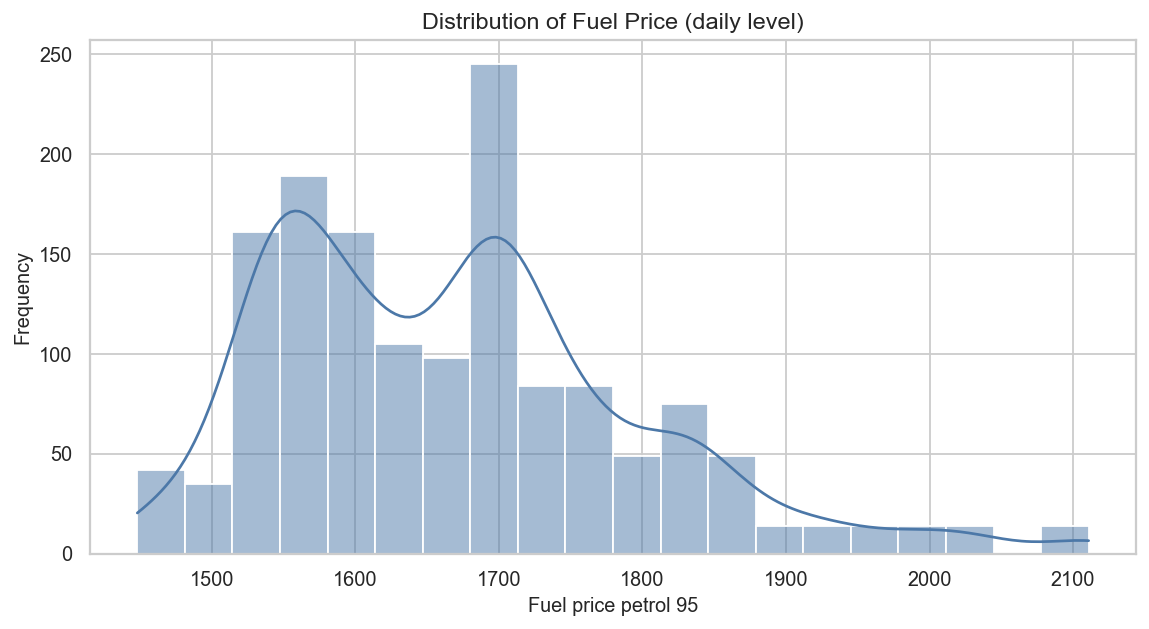

In [33]:
# -------------------------
# Histogram + KDE (daily-level)
# -------------------------
plt.figure(figsize=(9, 5))
sns.histplot(
    fuel_daily_nonmissing["FuelPrice"],
    bins=20,
    kde=True,
    color="#4C78A8"
)
plt.title("Distribution of Fuel Price (daily level)")
plt.xlabel("Fuel price petrol 95")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(eda_folder / "fuelprice_distribution_daily_hist.png", bbox_inches="tight")
plt.show()
plt.close()

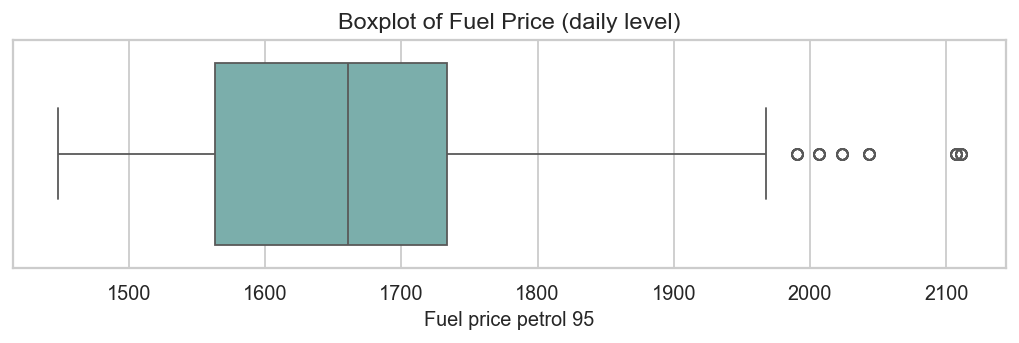

In [34]:
# -------------------------
# Box plot (daily-level)
# -------------------------
plt.figure(figsize=(8, 2.8))
sns.boxplot(
    x=fuel_daily_nonmissing["FuelPrice"],
    color="#72B7B2",
    showfliers=True
)
plt.title("Boxplot of Fuel Price (daily level)")
plt.xlabel("Fuel price petrol 95")
plt.tight_layout()
plt.savefig(eda_folder / "fuelprice_distribution_daily_boxplot.png", bbox_inches="tight")
plt.show()
plt.close()

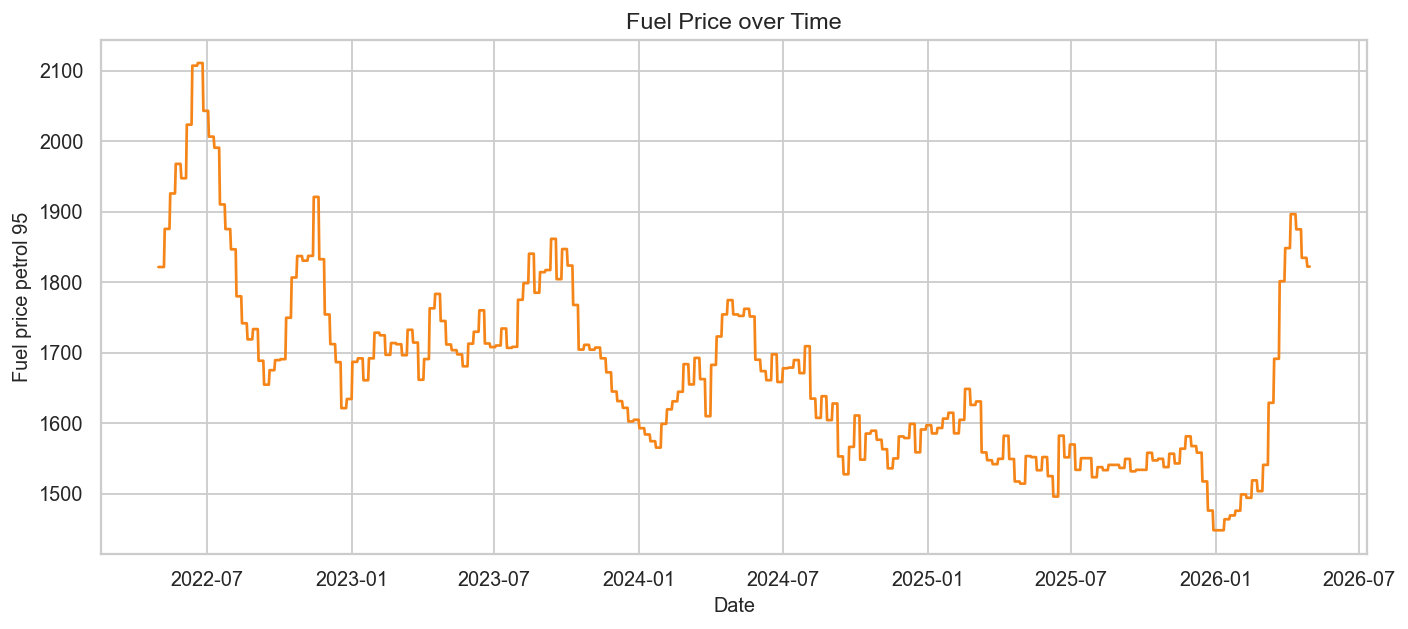

In [35]:
# -------------------------
# Time-series plot
# -------------------------
plt.figure(figsize=(11, 5))
sns.lineplot(
    data=fuel_daily_nonmissing,
    x="date",
    y="FuelPrice",
    color="#F58518"
)
plt.title("Fuel Price over Time")
plt.xlabel("Date")
plt.ylabel("Fuel price petrol 95")
plt.tight_layout()
plt.savefig(eda_folder / "fuelprice_time_series.png", bbox_inches="tight")
plt.show()
plt.close()

In [36]:
# -------------------------
# Descriptive statistics
# -------------------------
fuel_desc = (
    fuel_daily_nonmissing["FuelPrice"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .reset_index()
)
fuel_desc.columns = ["statistic", "value"]

fuel_desc.to_csv(eda_folder / "fuelprice_descriptive_stats.csv", index=False)
fuel_desc

,statistic,value
0,count,1461.000000
1,mean,1669.364120
2,std,127.663834
3,min,1448.200000
4,1%,1463.840000
5,5%,1514.330000
6,25%,1563.120000
7,50%,1660.990000
8,75%,1733.500000
9,95%,1910.240000


### Data exploration for response variable (count_rescaled)

In [37]:
response_var = "count_rescaled"
response_df=df.copy()
response_df["Outcome"] = response_df[response_var]

# -------------------------
# Basic count / completeness summary
# -------------------------
response_count_summary = pd.DataFrame({
    "metric": [
        "total_rows",
        "non_missing_rows",
        "missing_rows",
        "missing_share",
        "zero_rows",
        "zero_share",
        "unique_values"
    ],
    "value": [
        len(response_df),
        response_df["Outcome"].notna().sum(),
        response_df["Outcome"].isna().sum(),
        response_df["Outcome"].isna().mean(),
        (response_df["Outcome"] == 0).sum(),
        (response_df["Outcome"] == 0).mean(),
        response_df["Outcome"].nunique()
    ]
})

response_count_summary.to_csv(eda_folder / "response_count_summary.csv", index=False)
response_count_summary

,metric,value
0,total_rows,4.587736e+06
1,non_missing_rows,4.587736e+06
2,missing_rows,0.000000e+00
3,missing_share,0.000000e+00
4,zero_rows,1.254674e+06
5,zero_share,2.734844e-01
6,unique_values,1.167000e+03


There is missing value in count_rescaled, but many 0 values.

In [38]:
# -------------------------
# Binned counts table
# -------------------------
n_bins = 30

response_nonmissing = response_df.dropna(subset=["Outcome"]).copy()

response_nonmissing["Outcome_bin"] = pd.cut(
    response_nonmissing["Outcome"],
    bins=n_bins
)

response_bin_counts = (
    response_nonmissing["Outcome_bin"]
    .value_counts(sort=False)
    .rename_axis("Outcome_bin")
    .reset_index(name="n")
)

response_bin_counts["share"] = response_bin_counts["n"] / response_bin_counts["n"].sum()

response_bin_counts.to_csv(eda_folder / "response_binned_counts.csv", index=False)
response_bin_counts

,Outcome_bin,n,share
0,"(-8.682, 289.4]",4560355,9.940317e-01
1,"(289.4, 578.8]",24548,5.350787e-03
2,"(578.8, 868.2]",2498,5.444951e-04
3,"(868.2, 1157.6]",236,5.144150e-05
4,"(1157.6, 1447.0]",40,8.718898e-06
5,"(1447.0, 1736.4]",33,7.193090e-06
6,"(1736.4, 2025.8]",8,1.743780e-06
7,"(2025.8, 2315.2]",4,8.718898e-07
8,"(2315.2, 2604.6]",4,8.718898e-07
9,"(2604.6, 2894.0]",2,4.359449e-07


Most of the observations lower than 289.4, and larges values lead to right-skew.

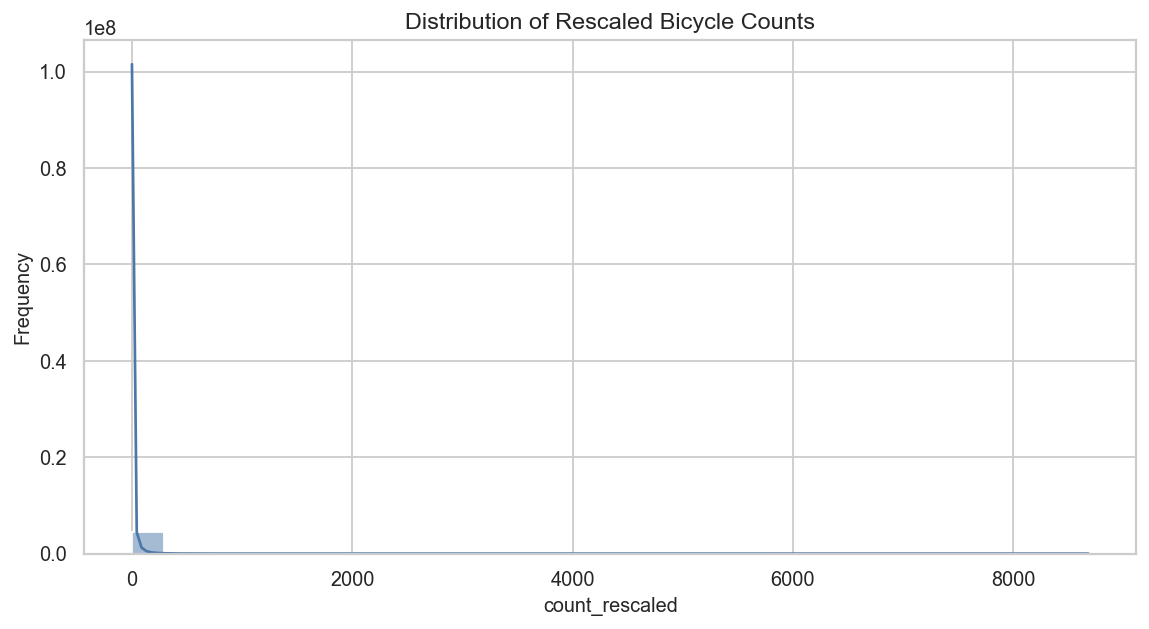

In [39]:
# -------------------------
# Histogram + KDE
# -------------------------
plt.figure(figsize=(9, 5))
sns.histplot(
    response_nonmissing["Outcome"],
    bins=30,
    kde=True,
    color="#4C78A8"
)
plt.title("Distribution of Rescaled Bicycle Counts")
plt.xlabel("count_rescaled")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(eda_folder / "response_distribution_hist.png", bbox_inches="tight")
plt.show()
plt.close()

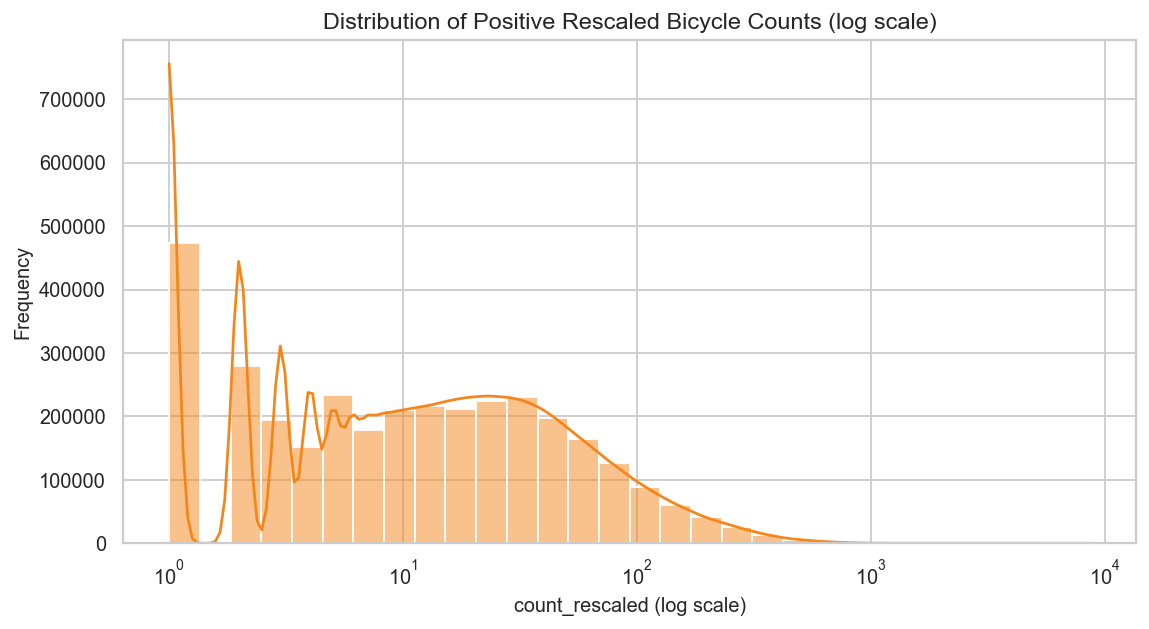

In [40]:
# -------------------------
# log-scale histogram
# -------------------------
response_positive = response_nonmissing[response_nonmissing["Outcome"] > 0].copy()

plt.figure(figsize=(9, 5))
sns.histplot(
    response_positive["Outcome"],
    bins=30,
    kde=True,
    color="#F58518",
    log_scale=True
)
plt.title("Distribution of Positive Rescaled Bicycle Counts (log scale)")
plt.xlabel("count_rescaled (log scale)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(eda_folder / "response_distribution_hist_logscale.png", bbox_inches="tight")
plt.show()
plt.close()

In [41]:
# -------------------------
# Descriptive statistics
# -------------------------
response_desc = (
    response_nonmissing["Outcome"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .reset_index()
)
response_desc.columns = ["statistic", "value"]

response_desc.to_csv(eda_folder / "response_descriptive_stats.csv", index=False)
response_desc

,statistic,value
0,count,4.587736e+06
1,mean,2.135952e+01
2,std,4.899167e+01
3,min,0.000000e+00
4,1%,0.000000e+00
5,5%,0.000000e+00
6,25%,0.000000e+00
7,50%,4.000000e+00
8,75%,2.100000e+01
9,95%,9.600000e+01


### Correlation analysis

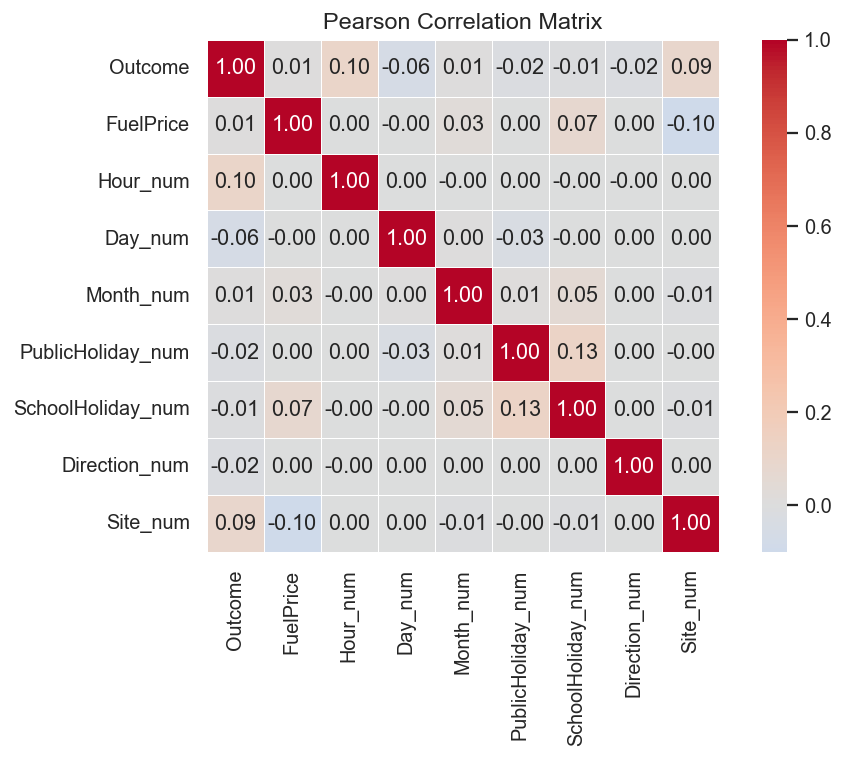

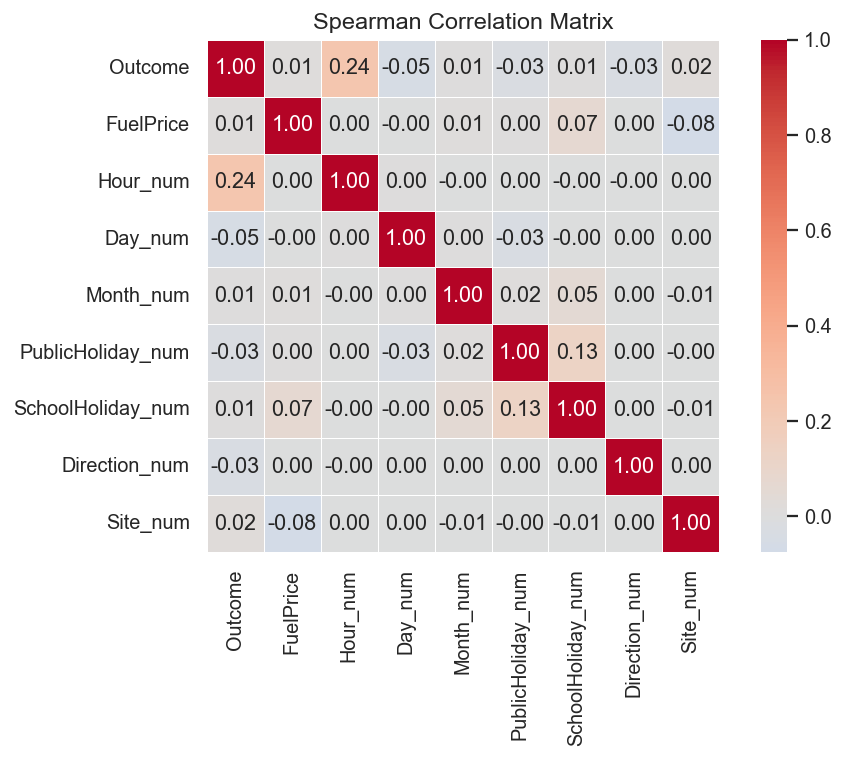

,Pearson_with_Outcome,Spearman_with_Outcome
Outcome,1.000000,1.000000
Hour_num,0.103492,0.242499
Day_num,-0.059537,-0.047859
Direction_num,-0.017144,-0.034568
PublicHoliday_num,-0.022716,-0.026078
Site_num,0.089036,0.021813
FuelPrice,0.007876,0.013438
Month_num,0.010085,0.008646
SchoolHoliday_num,-0.014179,0.005545


In [42]:


# output folder
projectfolder = Path("..")
processedfolder = projectfolder / "data" / "processed"
edafolder = processedfolder / "edamodel1"
edafolder.mkdir(parents=True, exist_ok=True)

# correlation data
corrdf = df.copy()
corrdf["Outcome"] = corrdf["count_rescaled"]
corrdf["FuelPrice"] = corrdf["fuel_price_petrol_95"]

corrdf["Hour_num"] = pd.to_numeric(corrdf["hour_bin"], errors="coerce")
corrdf["Day_num"] = pd.Categorical(
    corrdf["weekday"],
    categories=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    ordered=True
).codes + 1
corrdf["Month_num"] = pd.Categorical(
    corrdf["month"],
    categories=list(range(1, 13)),
    ordered=True
).codes + 1
corrdf["PublicHoliday_num"] = corrdf["is_public_holiday"].astype(float)
corrdf["SchoolHoliday_num"] = corrdf["is_school_holiday"].astype(float)
corrdf["Direction_num"] = corrdf["direction"].map({"IN": 0, "OUT": 1}).astype(float)
corrdf["Site_num"] = pd.to_numeric(corrdf["site_id"], errors="coerce")

corr_vars = [
    "Outcome",
    "FuelPrice",
    "Hour_num",
    "Day_num",
    "Month_num",
    "PublicHoliday_num",
    "SchoolHoliday_num",
    "Direction_num",
    "Site_num"
]

corrdata = corrdf[corr_vars].dropna().copy()

pearson_corr = corrdata.corr(method="pearson")
spearman_corr = corrdata.corr(method="spearman")

pearson_corr.to_csv(edafolder / "correlation_matrix_pearson.csv", index=True)
spearman_corr.to_csv(edafolder / "correlation_matrix_spearman.csv", index=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.savefig(edafolder / "correlation_matrix_pearson.png", bbox_inches="tight")
plt.show()
plt.close()

# Spearman correlation
spearman_corr = corrdata.corr(method="spearman")
spearman_corr.to_csv(edafolder / "correlation_matrix_spearman.csv", index=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.savefig(edafolder / "correlation_matrix_spearman.png", bbox_inches="tight")
plt.show()
plt.close()

# Correlation with outcome only
outcome_corr = pd.DataFrame({
    "Pearson_with_Outcome": pearson_corr["Outcome"],
    "Spearman_with_Outcome": spearman_corr["Outcome"]
}).sort_values("Spearman_with_Outcome", key=lambda s: s.abs(), ascending=False)

outcome_corr.to_csv(edafolder / "outcome_correlation_summary.csv", index=True)
outcome_corr